# Chapter-02. Tensor的操作

## 【章节目标】
- 理解轴向的概念
- 掌握tensor的拼接和切分
- 掌握tensor的索引
- 掌握tensor的变换

## 【章节内容】

### 2.1 axis轴向理解
轴的概念，表示沿着某个维度（rank）进行操作，和rank等价，举例如下  
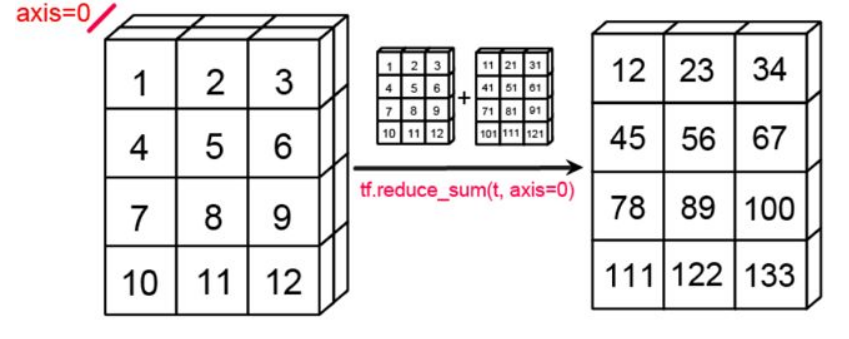  
axis=0时，操作是沿着rank=0的方向进行的。

代码演示：

In [1]:
import torch
a = torch.arange(1, 25).reshape(2, 4, 3)
a

tensor([[[ 1,  2,  3],
         [ 4,  5,  6],
         [ 7,  8,  9],
         [10, 11, 12]],

        [[13, 14, 15],
         [16, 17, 18],
         [19, 20, 21],
         [22, 23, 24]]])

In [2]:
a.sum(axis = 0)

tensor([[14, 16, 18],
        [20, 22, 24],
        [26, 28, 30],
        [32, 34, 36]])

In [3]:
a.sum(axis = 1)

tensor([[22, 26, 30],
        [70, 74, 78]])

### 2.2 Tensor拼接与切分
#### 1） torch.cat()
功能：在某个axis上连接tensor，dim不变（原来dim=3，拼接后dim=3）。

- tensors: 张量序列
- dim : 要拼接的维度  
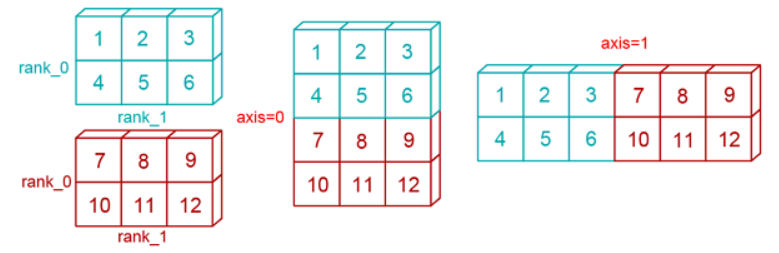  
代码演示：

In [4]:
a = torch.arange(1, 7).reshape(2, 3)
b = torch.arange(7, 13).reshape(2, 3)
a, b

(tensor([[1, 2, 3],
         [4, 5, 6]]),
 tensor([[ 7,  8,  9],
         [10, 11, 12]]))

In [5]:
torch.cat([a, b], axis = 0)

tensor([[ 1,  2,  3],
        [ 4,  5,  6],
        [ 7,  8,  9],
        [10, 11, 12]])

In [6]:
torch.cat([a, b], dim = 1)

tensor([[ 1,  2,  3,  7,  8,  9],
        [ 4,  5,  6, 10, 11, 12]])

#### 2） torch.stack()
功能：在新创建的维度dim上进行拼接,增加一个维度进行拼合，相当与对原张量进行各种翻转然后叠加在一起。

- tensors:张量序列
- dim :要拼接的维度

代码演示：

In [7]:
a = torch.arange(1, 7).reshape(2, 3)
b = torch.arange(7, 13).reshape(2, 3)
a, b

(tensor([[1, 2, 3],
         [4, 5, 6]]),
 tensor([[ 7,  8,  9],
         [10, 11, 12]]))

1.dim=0：增加一个0维，无需翻转。  
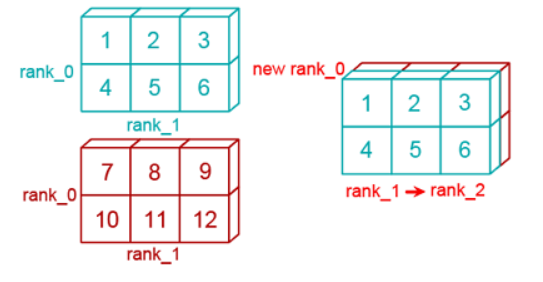

In [8]:
torch.stack([a, b], dim = 0)

tensor([[[ 1,  2,  3],
         [ 4,  5,  6]],

        [[ 7,  8,  9],
         [10, 11, 12]]])

In [11]:
a1 = a.view(1, 2, 3)
b1 = b.view(1, 2, 3)
a1, b1, a1.shape, b1.shape

(tensor([[[1, 2, 3],
          [4, 5, 6]]]),
 tensor([[[ 7,  8,  9],
          [10, 11, 12]]]),
 torch.Size([1, 2, 3]),
 torch.Size([1, 2, 3]))

In [12]:
torch.cat([a1, b1], dim = 0)

tensor([[[ 1,  2,  3],
         [ 4,  5,  6]],

        [[ 7,  8,  9],
         [10, 11, 12]]])

2.dim=1:增加一个1维，形象看，相当于翻转一次，再叠加。  
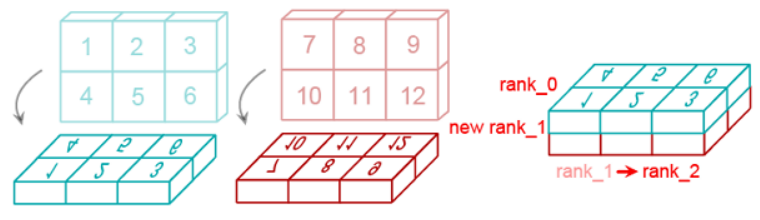

In [13]:
torch.stack([a, b], dim = 1) # shape=(2,2,3)

tensor([[[ 1,  2,  3],
         [ 7,  8,  9]],

        [[ 4,  5,  6],
         [10, 11, 12]]])

In [14]:
a1 = a.view(2, 1, 3)
b1 = b.view(2, 1, 3)
a1, b1, a1.shape, b1.shape

(tensor([[[1, 2, 3]],
 
         [[4, 5, 6]]]),
 tensor([[[ 7,  8,  9]],
 
         [[10, 11, 12]]]),
 torch.Size([2, 1, 3]),
 torch.Size([2, 1, 3]))

In [15]:
torch.cat([a1, b1], dim = 1)

tensor([[[ 1,  2,  3],
         [ 7,  8,  9]],

        [[ 4,  5,  6],
         [10, 11, 12]]])

3.dim=2：增加一个2维，形象看，相当于翻转两次，再叠加。  
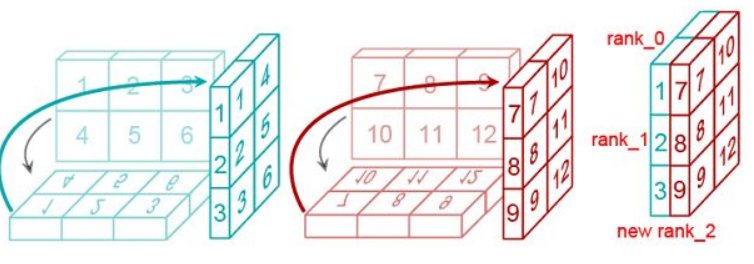

In [16]:
torch.stack([a, b], dim = 2) # shape=(2,3,2)

tensor([[[ 1,  7],
         [ 2,  8],
         [ 3,  9]],

        [[ 4, 10],
         [ 5, 11],
         [ 6, 12]]])

In [17]:
a1 = a.view(2, 3, 1)
b1 = b.view(2, 3, 1)
a1, b1, a1.shape, b1.shape

(tensor([[[1],
          [2],
          [3]],
 
         [[4],
          [5],
          [6]]]),
 tensor([[[ 7],
          [ 8],
          [ 9]],
 
         [[10],
          [11],
          [12]]]),
 torch.Size([2, 3, 1]),
 torch.Size([2, 3, 1]))

In [18]:
torch.cat([a1, b1], dim = 2)

tensor([[[ 1,  7],
         [ 2,  8],
         [ 3,  9]],

        [[ 4, 10],
         [ 5, 11],
         [ 6, 12]]])

#### 3） torch.chunk()
- 功能：将张量按维度dim进行平均切分
- 返回值：张量列表
- 注意事项：若不能整除，最后一份张量小于其他张量
    - input: 要切分的张量
    - chunks : 要切分的份数
    - dim : 要切分的维度  
    
代码演示：

In [19]:
a = torch.arange(1, 25).reshape(2, 3, 4)
a

tensor([[[ 1,  2,  3,  4],
         [ 5,  6,  7,  8],
         [ 9, 10, 11, 12]],

        [[13, 14, 15, 16],
         [17, 18, 19, 20],
         [21, 22, 23, 24]]])

In [20]:
torch.chunk(a, 2, dim = 2)

(tensor([[[ 1,  2],
          [ 5,  6],
          [ 9, 10]],
 
         [[13, 14],
          [17, 18],
          [21, 22]]]),
 tensor([[[ 3,  4],
          [ 7,  8],
          [11, 12]],
 
         [[15, 16],
          [19, 20],
          [23, 24]]]))

In [21]:
torch.chunk(a, 2, dim = 1)

(tensor([[[ 1,  2,  3,  4],
          [ 5,  6,  7,  8]],
 
         [[13, 14, 15, 16],
          [17, 18, 19, 20]]]),
 tensor([[[ 9, 10, 11, 12]],
 
         [[21, 22, 23, 24]]]))

In [22]:
torch.chunk(a, 2, dim = 0)

(tensor([[[ 1,  2,  3,  4],
          [ 5,  6,  7,  8],
          [ 9, 10, 11, 12]]]),
 tensor([[[13, 14, 15, 16],
          [17, 18, 19, 20],
          [21, 22, 23, 24]]]))

#### 4） torch.split()
- 功能：将张量按维度dim进行切分

- 返回值：张量列表

    - tensor: 要切分的张量
    - split_size_or_sections : 为int时，表示每一份的长度；为list时，按list元素切分
    - dim : 要切分的维度

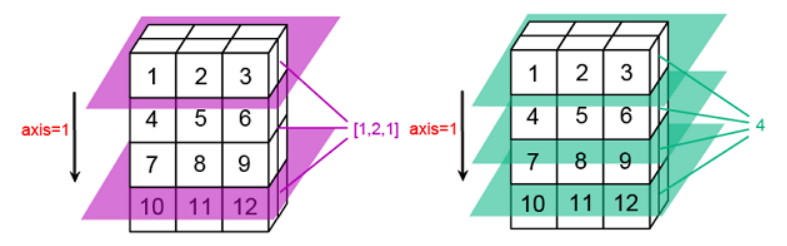  

代码演示：

In [23]:
a = torch.arange(1, 25).reshape(2, 4, 3)
a

tensor([[[ 1,  2,  3],
         [ 4,  5,  6],
         [ 7,  8,  9],
         [10, 11, 12]],

        [[13, 14, 15],
         [16, 17, 18],
         [19, 20, 21],
         [22, 23, 24]]])

In [24]:
torch.split(a, [1, 2, 1], dim = 1)

(tensor([[[ 1,  2,  3]],
 
         [[13, 14, 15]]]),
 tensor([[[ 4,  5,  6],
          [ 7,  8,  9]],
 
         [[16, 17, 18],
          [19, 20, 21]]]),
 tensor([[[10, 11, 12]],
 
         [[22, 23, 24]]]))

In [26]:
torch.split(a, [1, 2], dim = 2)

(tensor([[[ 1],
          [ 4],
          [ 7],
          [10]],
 
         [[13],
          [16],
          [19],
          [22]]]),
 tensor([[[ 2,  3],
          [ 5,  6],
          [ 8,  9],
          [11, 12]],
 
         [[14, 15],
          [17, 18],
          [20, 21],
          [23, 24]]]))

### 2.3 张量索引
#### 1） 像numpy一样直接索引
- 索引：a[0,1,2]
- 切片：a[0:2,1,1:]

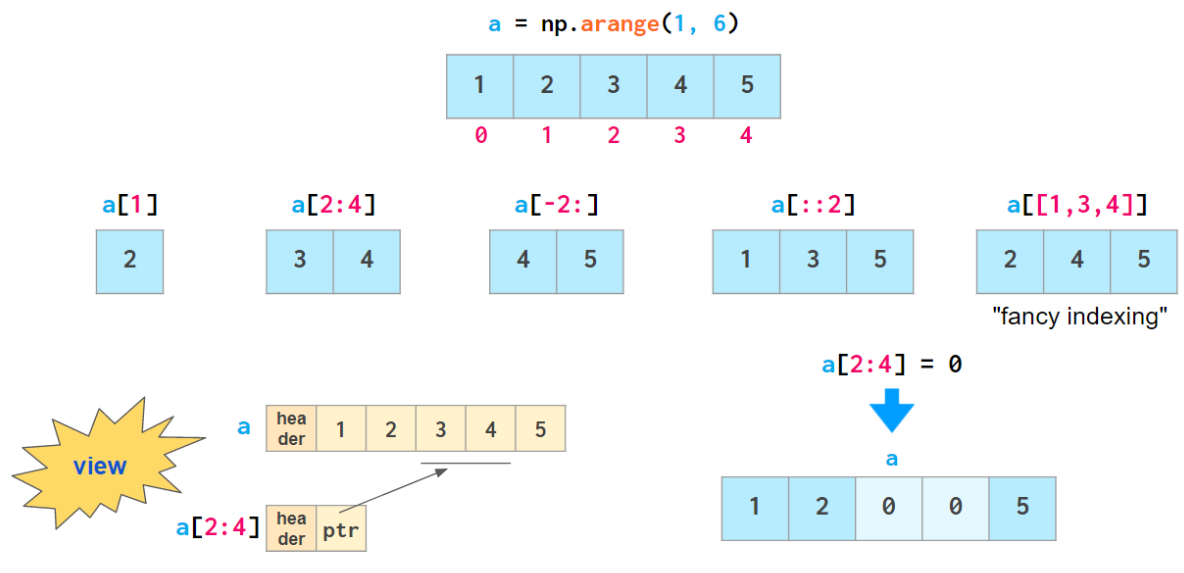

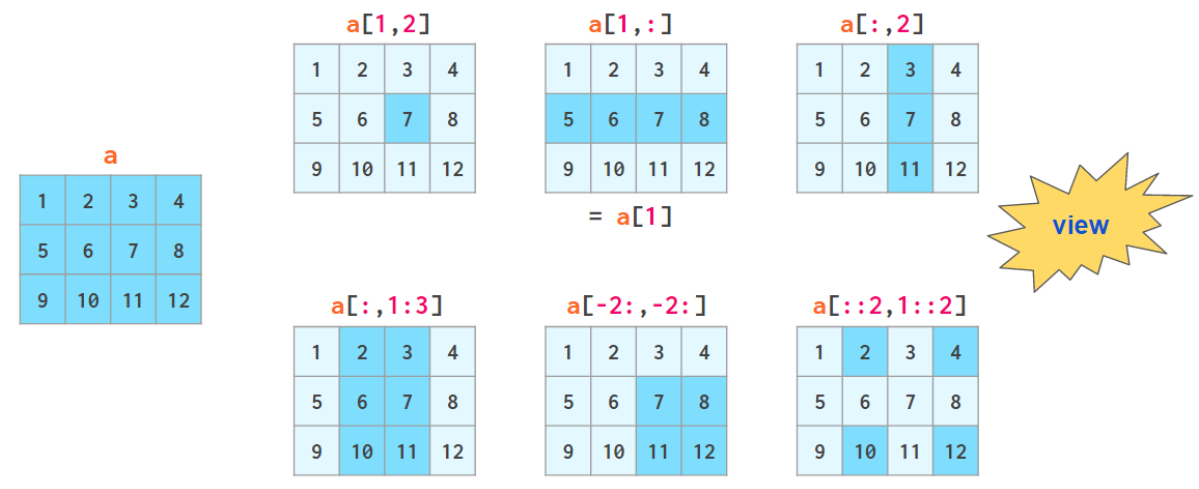

代码演示：

In [27]:
a = torch.arange(1, 25).reshape(2, 4, 3)
a

tensor([[[ 1,  2,  3],
         [ 4,  5,  6],
         [ 7,  8,  9],
         [10, 11, 12]],

        [[13, 14, 15],
         [16, 17, 18],
         [19, 20, 21],
         [22, 23, 24]]])

In [28]:
a[0]

tensor([[ 1,  2,  3],
        [ 4,  5,  6],
        [ 7,  8,  9],
        [10, 11, 12]])

In [29]:
a[0, 1]

tensor([4, 5, 6])

In [30]:
a[0, 1, 2]

tensor(6)

In [32]:
a[1:] # 切片维度保留，索引会降维

tensor([[[13, 14, 15],
         [16, 17, 18],
         [19, 20, 21],
         [22, 23, 24]]])

#### 2） 逻辑索引

跟numpy一样  
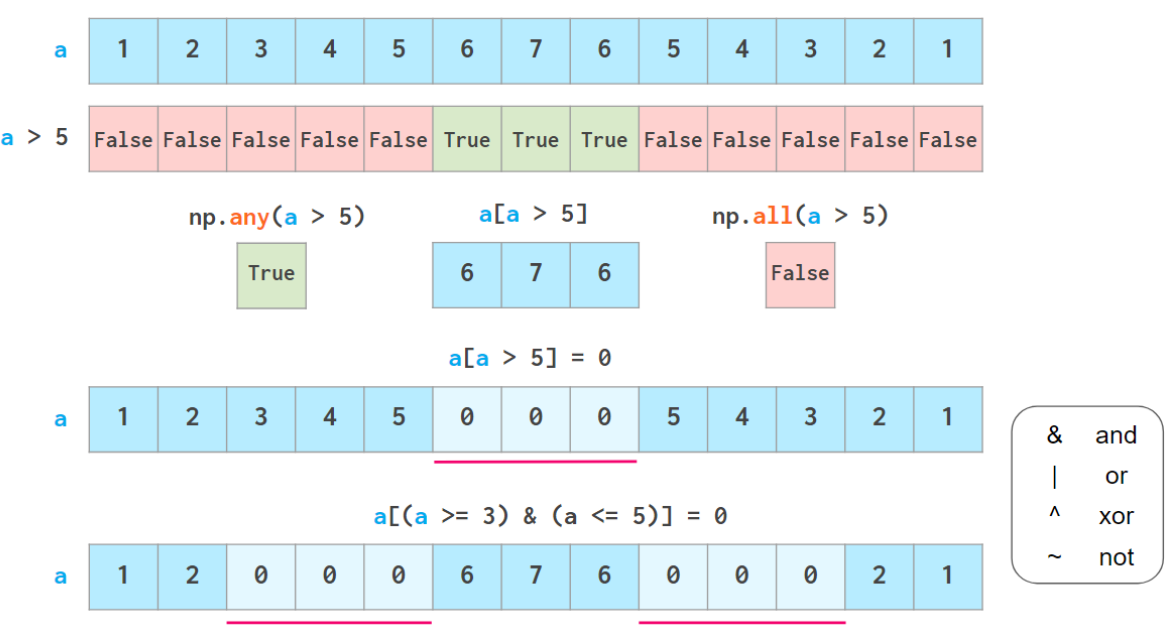

In [33]:
a = torch.arange(1, 13).reshape(3, 4)
a

tensor([[ 1,  2,  3,  4],
        [ 5,  6,  7,  8],
        [ 9, 10, 11, 12]])

In [34]:
a > 7

tensor([[False, False, False, False],
        [False, False, False,  True],
        [ True,  True,  True,  True]])

In [36]:
a[a > 7] # 逻辑索引返回的一定是一维tensor

tensor([ 8,  9, 10, 11, 12])

In [37]:
a[(a > 3) & (a < 5)]

tensor([4])

#### 3） torch.index_select()
- 功能：在维度dim上，按index索引数据
- 返回值：依index索引数据拼接的张量
- input: 要索引的张量
- dim: 要索引的维度
- index : 要索引数据的序号

代码演示：

In [39]:
torch.index_select(a, dim = 1, index = torch.tensor([0, 2])) # index必须是tensor

tensor([[ 1,  3],
        [ 5,  7],
        [ 9, 11]])

#### 4） torch.masked_select()
- 功能：按mask中的True进行索引
- 返回值：一维张量
- input: 要索引的张量
- mask: 与input同形状的布尔类型张量

代码演示：

In [40]:
torch.masked_select(a, mask = a > 7)

tensor([ 8,  9, 10, 11, 12])

### 2.4 张量变换
#### 1） torch.reshape()
- 功能：变换张量形状

- 注意事项：当张量在内存中是连续时，新张量与input共享数据内存

    - input: 要变换的张量
    - shape: 新张量的形状

    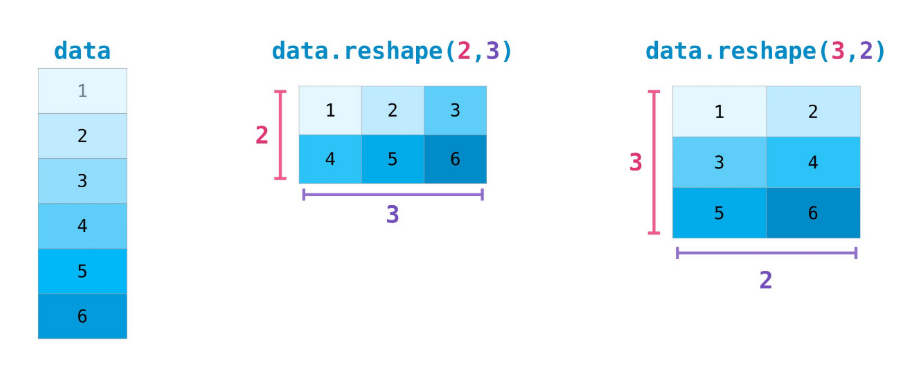

    代码演示：

In [41]:
a = torch.arange(1, 7)
a

tensor([1, 2, 3, 4, 5, 6])

In [45]:
torch.reshape(a, [2, 3]) # 调用模块的全局方法

tensor([[1, 2, 3],
        [4, 5, 6]])

In [46]:
a.reshape([2, 3]) # 这个方法的底层依然是调用全局方法

tensor([[1, 2, 3],
        [4, 5, 6]])

In [44]:
a.reshape([3, 2])

tensor([[1, 2],
        [3, 4],
        [5, 6]])

#### 2） torch.transpose()

功能：交换张量的两个维度

- input: 要变换的张量
- dim0: 要交换的维度
- dim1: 要交换的维度

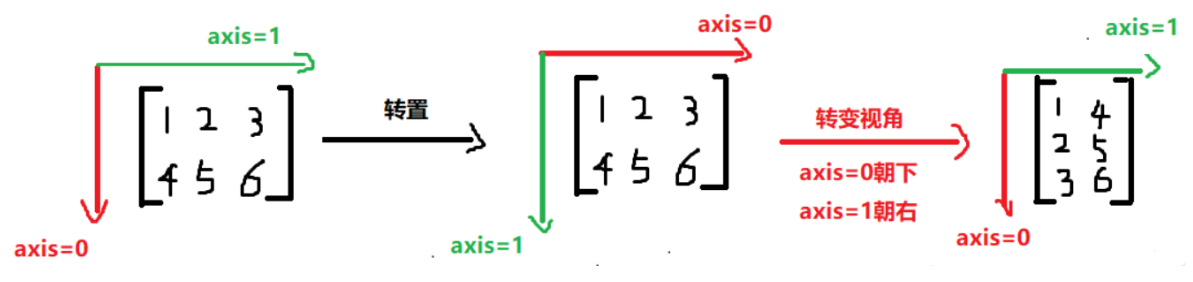

代码演示：

In [47]:
a = torch.arange(1, 7).reshape(2, 3)
a

tensor([[1, 2, 3],
        [4, 5, 6]])

In [48]:
torch.transpose(a, dim0 = 1, dim1 = 0)

tensor([[1, 4],
        [2, 5],
        [3, 6]])

In [50]:
b = torch.arange(1, 25).reshape(2, 3, 4)
b

tensor([[[ 1,  2,  3,  4],
         [ 5,  6,  7,  8],
         [ 9, 10, 11, 12]],

        [[13, 14, 15, 16],
         [17, 18, 19, 20],
         [21, 22, 23, 24]]])

In [51]:
b.transpose(dim0 = 0, dim1 = 2)

tensor([[[ 1, 13],
         [ 5, 17],
         [ 9, 21]],

        [[ 2, 14],
         [ 6, 18],
         [10, 22]],

        [[ 3, 15],
         [ 7, 19],
         [11, 23]],

        [[ 4, 16],
         [ 8, 20],
         [12, 24]]])

In [52]:
torch.t(a) # 二维矩阵专用，等价于torch.transpose(a,dim0=1,dim1=0)

tensor([[1, 4],
        [2, 5],
        [3, 6]])

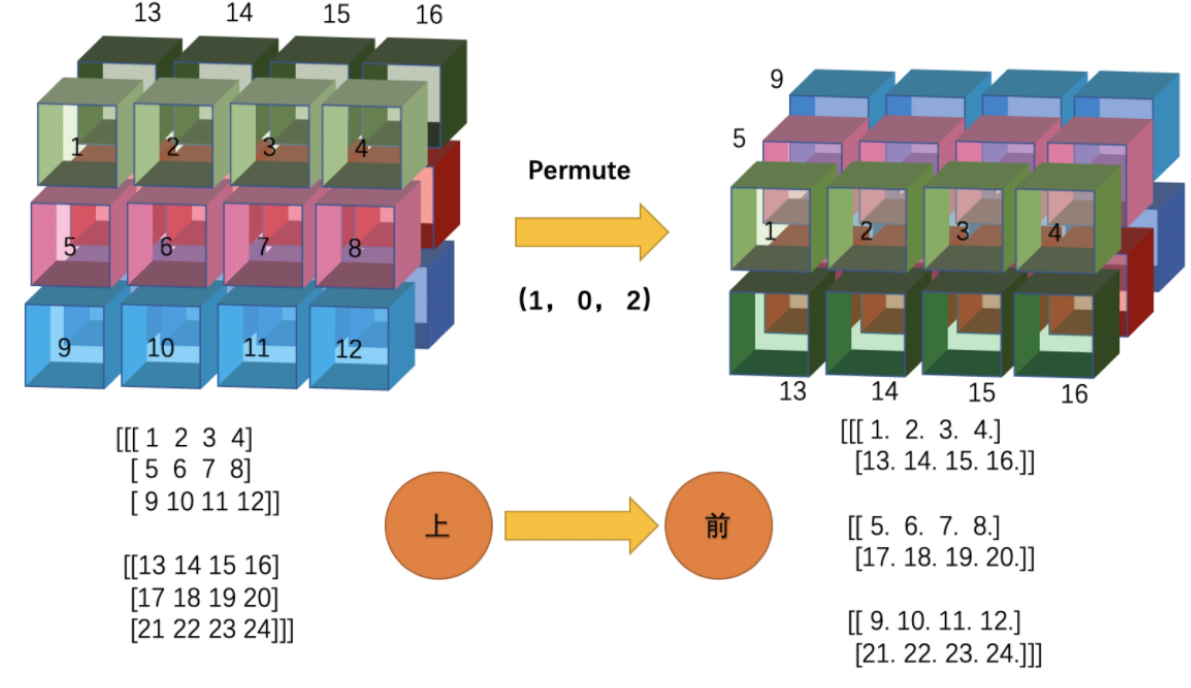

In [53]:
a = torch.arange(1, 25).reshape(2, 3, 4)
a

tensor([[[ 1,  2,  3,  4],
         [ 5,  6,  7,  8],
         [ 9, 10, 11, 12]],

        [[13, 14, 15, 16],
         [17, 18, 19, 20],
         [21, 22, 23, 24]]])

In [54]:
torch.transpose(a, dim0 = 1, dim1 = 0)

tensor([[[ 1,  2,  3,  4],
         [13, 14, 15, 16]],

        [[ 5,  6,  7,  8],
         [17, 18, 19, 20]],

        [[ 9, 10, 11, 12],
         [21, 22, 23, 24]]])

#### 3） torch.squeeze()

功能：消除长度为1的维度（轴）  

- dim: 若为None，移除所有长度为1的轴； 若指定维度，当且仅当该轴长度为1时，可以被移除；

代码演示：

In [55]:
a=torch.arange(1,13).reshape(3,1,4)
a #shape=(2,1,3)   [1] 1  [1,2]

tensor([[[ 1,  2,  3,  4]],

        [[ 5,  6,  7,  8]],

        [[ 9, 10, 11, 12]]])

In [56]:
torch.squeeze(a) # shape = (2, 3)

tensor([[ 1,  2,  3,  4],
        [ 5,  6,  7,  8],
        [ 9, 10, 11, 12]])

In [57]:
torch.squeeze(a, dim = 2) # dim = 2的维度长度不为1，无法消除

tensor([[[ 1,  2,  3,  4]],

        [[ 5,  6,  7,  8]],

        [[ 9, 10, 11, 12]]])

#### 4） torch.unsqueeze()

功能：依据dim扩展维度

- dim: 扩展的维度

In [58]:
a = torch.arange(1, 7).reshape(2, 3)
a

tensor([[1, 2, 3],
        [4, 5, 6]])

In [59]:
torch.unsqueeze(a, dim = 1) #shape:(2,3 )--->(2,1,3)

tensor([[[1, 2, 3]],

        [[4, 5, 6]]])

In [60]:
torch.unsqueeze(a, dim = 0)

tensor([[[1, 2, 3],
         [4, 5, 6]]])

### 2.5 Tensor存储模式理解

Tensor在存储的时候分为两部分：

- storage：数据的底层存储，是一个一维数组
- view：视图，如何去观察和读取数据

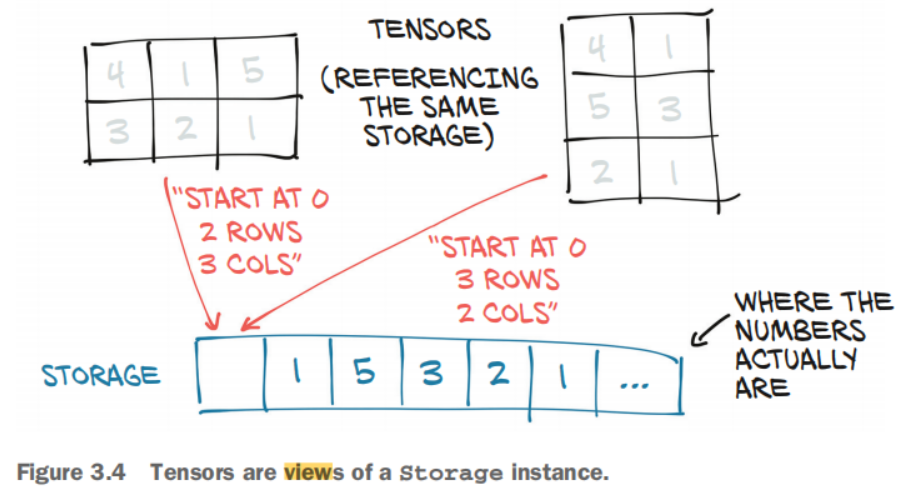

代码演示：

In [61]:
a = torch.arange(1, 7)
a

tensor([1, 2, 3, 4, 5, 6])

In [62]:
b = a.reshape(2, 3)
b

tensor([[1, 2, 3],
        [4, 5, 6]])

In [63]:
a[0] = 5
b

tensor([[5, 2, 3],
        [4, 5, 6]])

In [64]:
a

tensor([5, 2, 3, 4, 5, 6])

In [65]:
from copy import deepcopy
#使用deepcopy，这样就会将底层的storage也复制一份给b，否则赋值的仅仅是view
b = deepcopy(a.reshape(2, 3)) 
b

tensor([[5, 2, 3],
        [4, 5, 6]])

In [66]:
a[0] = 100
b

tensor([[5, 2, 3],
        [4, 5, 6]])

In [67]:
a

tensor([100,   2,   3,   4,   5,   6])